In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##Load dataset

In [ ]:
df=pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


##Data understanding and cleaning

In [ ]:
df.shape

(891, 12)

In [ ]:
df.columns.tolist()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


### Missing Values
- **Age:** about 20% missing → fill with the median.
- **Embarked:** less than 1% missing → fill with the mode.
- **Cabin:** about 77% missing → drop the column.

In [ ]:
df.duplicated().sum()

np.int64(0)

there is no duplication

In [ ]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df.drop(columns="Cabin", inplace=True)

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


##Visualization

###Histogram:

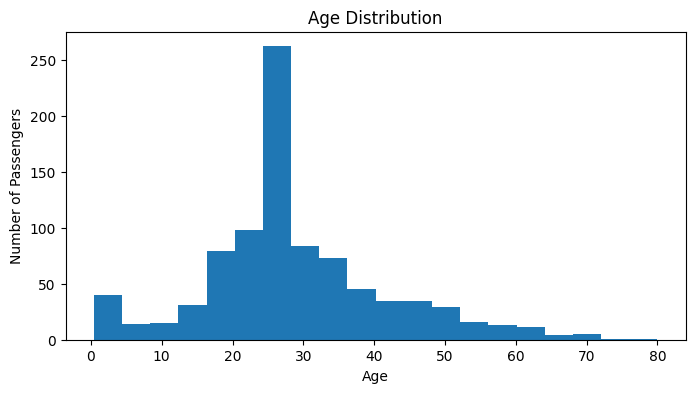

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(df["Age"], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

Most passengers were young adults (20–35 years old), while older passengers were fewer.

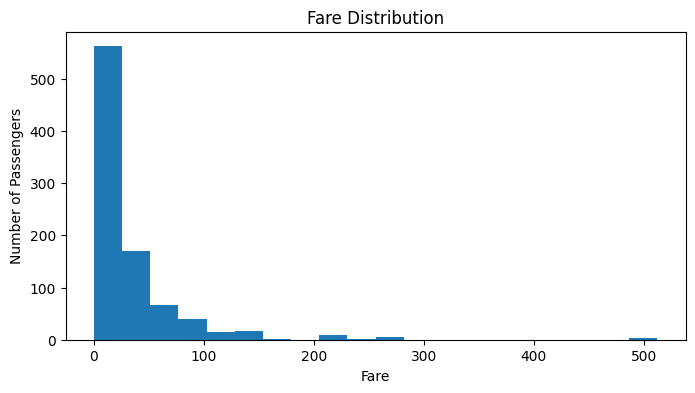

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(df["Fare"], bins=20)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.show()

Most passengers paid relatively low fares, while only a small number of passengers paid very high fares, indicating a right-skewed distribution.

###Bar plot:

In [ ]:
survival_by_gender = df.groupby("Sex")["Survived"].mean()

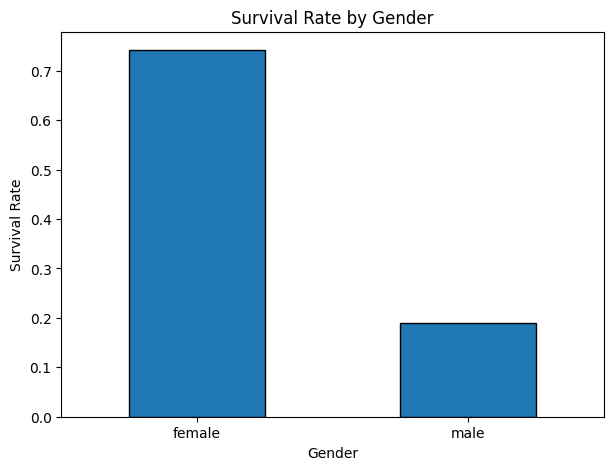

In [ ]:
plt.figure(figsize=(7, 5))
survival_by_gender.plot(kind="bar", edgecolor="black")

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.xticks(rotation=0)

plt.show()

Female passengers had a much higher survival rate than male passengers.

In [ ]:
pclass_counts = df["Pclass"].value_counts().sort_index()

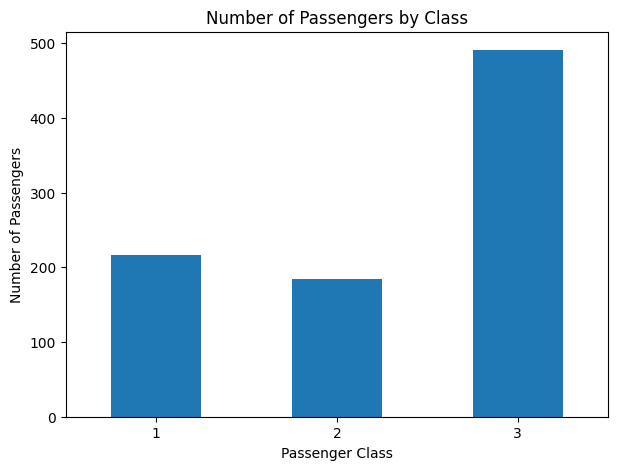

In [ ]:
plt.figure(figsize=(7, 5))
pclass_counts.plot(kind="bar")

plt.title("Number of Passengers by Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=0)

plt.show()

Most passengers traveled in third class, while first and second class had fewer passengers.

###count plot:

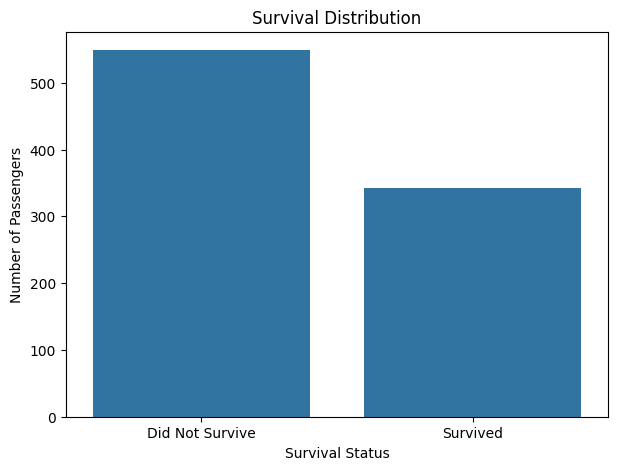

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Survived")

plt.title("Survival Distribution")
plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")
plt.xticks([0, 1], ["Did Not Survive", "Survived"])

plt.show()

More passengers did not survive than survived, indicating that the survival rate was relatively low.

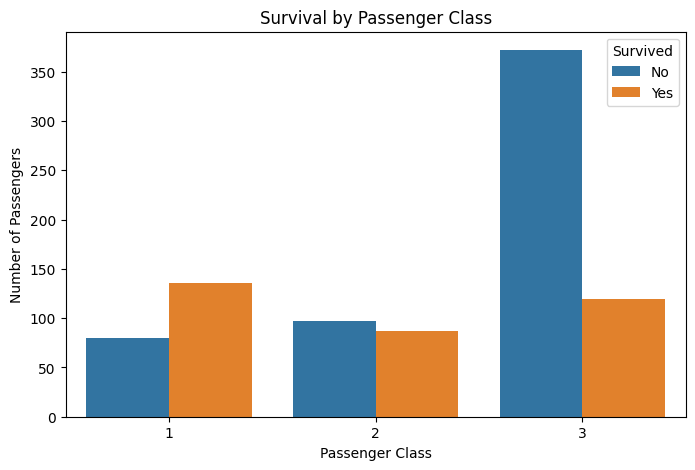

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Pclass", hue="Survived")

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])

plt.show()

First-class passengers had the highest survival rate, while third-class passengers had the lowest survival rate.

###Correlation heatmap:

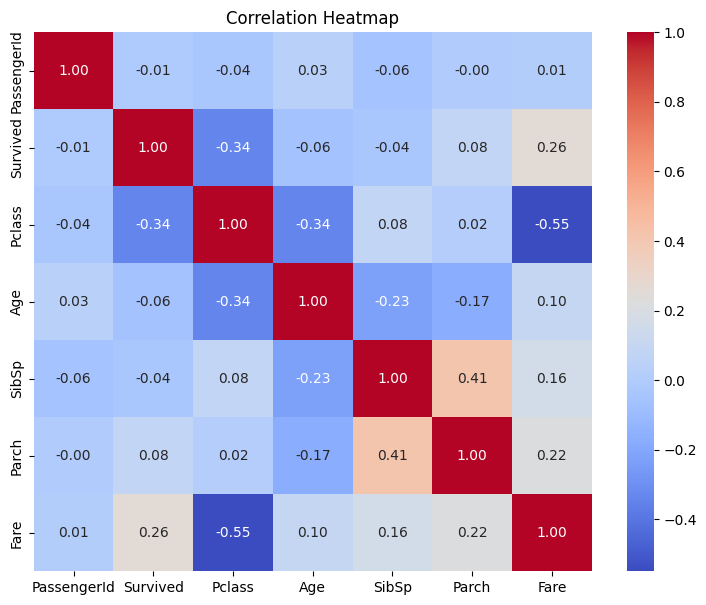

In [ ]:
plt.figure(figsize=(9, 7))
correlation = df.corr(numeric_only=True)

sns.heatmap(correlation,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Heatmap")

plt.show()

Passenger class and fare show the strongest relationship with survival, while SibSp and Parch are moderately correlated.